# Four neurons: nonlinear dynamics, flow learning, and repaired-path responses

This executable tutorial uses an invented four-neuron system with known equations.
It is for readers comfortable with arrays, conditional means and basic probability.
We will simulate independent recordings, train the same flow-matching head used in
the NeuroPAL program, and call the actual direct/progressive repaired-path samplers.

Three questions remain separate throughout:
1. What is the local derivative of the known transition equation?
2. What happens when we physically change a past state in this known simulator?
3. What changes when we softly condition model paths while keeping them near a
   factual trajectory? The third question is the NeuroPAL method's estimand.

This small demonstration is not evidence of biological causality or a new
54/80-neuron replication. CPU execution typically takes a few minutes.

In [1]:
from pathlib import Path
import sys, copy, time, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'data/archive_manifest.json').exists())
FROZEN = ROOT/'archive/fresh/replication_20260911/source'
sys.path.insert(0, str(FROZEN))
sys.path.insert(0, str(FROZEN/'history_tangent_benchmark/src'))
from history_tangent_benchmark.models import ConditionalFlowMatching
from compatibility_neural_benchmark.core import RepairedResponseConfig, generate_path_bank, estimate_repaired_responses
from compatibility_neural_benchmark.progressive_smc import progressive_smc_repaired_responses

import inspect
assert str(FROZEN) in inspect.getfile(ConditionalFlowMatching)
assert str(FROZEN) in inspect.getfile(progressive_smc_repaired_responses)
torch.set_num_threads(1)
np.random.seed(401); torch.manual_seed(401)
OUT = ROOT/'analysis/toy_outputs'; OUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})
NAMES = ['A', 'B', 'C', 'D']

def save_figure(fig, name):
    fig.tight_layout()
    for extension in ['png', 'pdf']:
        fig.savefig(OUT/f'{name}.{extension}', bbox_inches='tight')
    plt.show()

## 1. A known nonlinear system

The equations below predict time **t** from the three preceding frames. Noise is
independent standard Gaussian at each time and neuron, with a state-dependent
scale for D. All units and time steps are arbitrary.

A(t) = 0.55 A(t−1) + 0.25 sin(D(t−2)) + 0.20 εA

B(t) = 0.35 B(t−1) + 0.80 tanh(A(t−2)) + 0.22 εB

C(t) = 0.45 C(t−1) − 0.60 tanh(B(t−1))
       + 0.30 A(t−3) B(t−1) + 0.18 εC

D(t) = 0.40 D(t−1) + 0.70 tanh(C(t−3))
       + 0.18[1 + 0.4 sigmoid(A(t−1))] εD

The product in C makes its response depend on the current state. A fixed matrix
cannot fully describe this system, even though its equations are known.

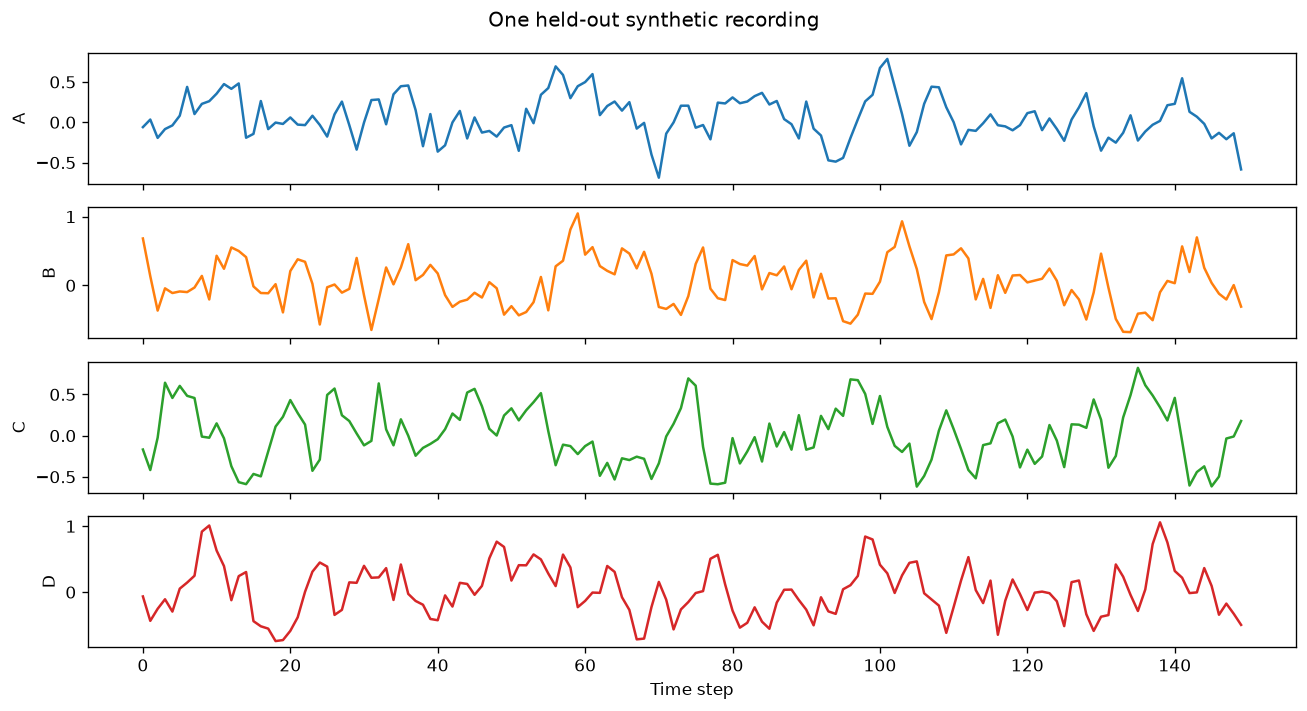

In [2]:
def conditional_mean(history):
    """history[..., oldest→newest, neuron]; output is the next raw state."""
    old, middle, last = history[..., -3, :], history[..., -2, :], history[..., -1, :]
    return np.stack([
        .55*last[..., 0] + .25*np.sin(middle[..., 3]),
        .35*last[..., 1] + .80*np.tanh(middle[..., 0]),
        .45*last[..., 2] - .60*np.tanh(last[..., 1]) + .30*old[..., 0]*last[..., 1],
        .40*last[..., 3] + .70*np.tanh(old[..., 2]),
    ], axis=-1)

def noise_scale(history):
    scale = np.broadcast_to([.20, .22, .18, .18], history.shape[:-2]+(4,)).copy()
    scale[..., 3] *= 1 + .4/(1 + np.exp(-history[..., -1, 0]))
    return scale

def simulate(seed, length=300, burn=100):
    rng = np.random.default_rng(seed)
    x = np.zeros((length+burn+3, 4))
    for t in range(3, len(x)):
        h = x[t-3:t]
        x[t] = conditional_mean(h) + noise_scale(h)*rng.normal(size=4)
    return x[-length:]

recordings = np.stack([simulate(1000+i) for i in range(24)])
np.savez_compressed(OUT/'recordings.npz', traces=recordings, seeds=np.arange(1000,1024))
fig, axes = plt.subplots(4, 1, figsize=(11, 6), sharex=True)
for j, ax in enumerate(axes):
    ax.plot(recordings[20, :150, j], color=f'C{j}'); ax.set_ylabel(NAMES[j])
axes[-1].set_xlabel('Time step'); fig.suptitle('One held-out synthetic recording')
save_figure(fig, '01_traces')

## 2. Split by recording and learn a conditional flow

Sixteen recordings train the model, four select the checkpoint, and four are held
out. Scaling uses training recordings only. The model learns the standardized
one-step residual, conditioned on the previous three standardized states.

For residual y, draw independent Gaussian z and τ uniformly in [0,1]. Regress
vθ((1−τ)z+τy, history, τ) onto y−z. At generation time, integrate vθ from z to a
residual, then add the latest observed state. We use the archived implementation
of that exact loss and its Heun sampler; the history encoder is a small flattened
history here, rather than the NeuroPAL TCN.

Trained 82 epochs in 0.8s; selected epoch 61.


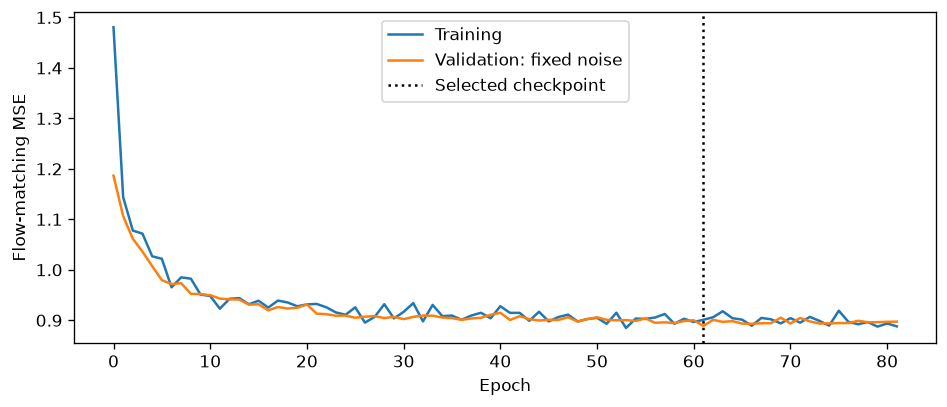

In [3]:
train_raw = recordings[:16].reshape(-1, 4)
center, scale = train_raw.mean(0), train_raw.std(0)
standardized = (recordings-center)/scale

def windows(ids):
    history, residual = [], []
    for i in ids:
        for t in range(3, standardized.shape[1]):
            h = standardized[i, t-3:t]
            history.append(h.reshape(-1)); residual.append(standardized[i,t]-h[-1])
    return torch.tensor(np.asarray(history), dtype=torch.float32), torch.tensor(np.asarray(residual), dtype=torch.float32)

train_h, train_y = windows(range(16))
val_h, val_y = windows(range(16,20))
test_h, test_y = windows(range(20,24))
flow = ConditionalFlowMatching(q=12, dy=4, hidden=64, layers=2, sample_steps=16)
optimizer = torch.optim.AdamW(flow.parameters(), lr=1e-3, weight_decay=1e-4)
trace = []; best = float('inf'); best_state = None; patience = 20
start = time.perf_counter()
for epoch in range(160):
    flow.train(); losses = []
    for ids in torch.randperm(len(train_h)).split(256):
        optimizer.zero_grad(); loss = flow.native_loss(train_h[ids], train_y[ids])
        loss.backward(); torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)
        optimizer.step(); losses.append(float(loss.detach()))
    flow.eval()
    with torch.no_grad(): validation = float(flow.validation_loss(val_h, val_y))
    trace.append((epoch, np.mean(losses), validation))
    if validation < best:
        best = validation; best_epoch = epoch; best_state = copy.deepcopy(flow.state_dict())
    if epoch-best_epoch >= patience: break
flow.load_state_dict(best_state); flow.eval()
training_seconds = time.perf_counter()-start
training_trace = pd.DataFrame(trace, columns=['epoch','training_loss','validation_loss'])
training_trace.to_csv(OUT/'training_trace.csv', index=False)
torch.save({'state_dict':best_state,'center':center,'scale':scale,'seed':401,'best_epoch':best_epoch}, OUT/'flow_checkpoint.pt')
print(f'Trained {len(trace)} epochs in {training_seconds:.1f}s; selected epoch {best_epoch}.')
fig, ax = plt.subplots(figsize=(8,3.5))
ax.plot(training_trace.epoch, training_trace.training_loss, label='Training')
ax.plot(training_trace.epoch, training_trace.validation_loss, label='Validation: fixed noise')
ax.axvline(best_epoch, color='k', ls=':', label='Selected checkpoint')
ax.set(xlabel='Epoch', ylabel='Flow-matching MSE'); ax.legend()
save_figure(fig, '02_training')

## 3. Check predictions before looking at effects

A flow trained on these finite data is an approximation. We compare its sampled
one-step mean with the exact transition mean on held-out histories. This check is
useful but does not certify conditional effects; the larger synthetic benchmark
explicitly demonstrates that distinction.

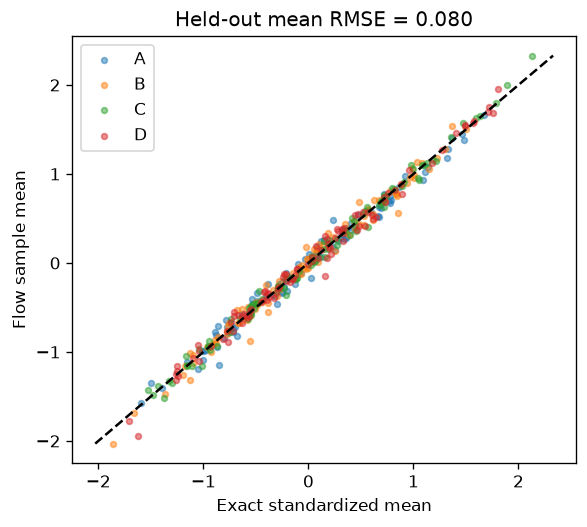

In [4]:
with torch.no_grad():
    h = test_h[::12]
    generated = flow.sample(h, 256, seed=405) + h.reshape(-1,3,4)[:,-1,None,:]
raw_history = h.numpy().reshape(-1,3,4)*scale+center
truth = (conditional_mean(raw_history)-center)/scale
predicted = generated.numpy().mean(1)
mean_rmse = float(np.sqrt(np.mean((truth-predicted)**2)))
np.savez_compressed(OUT/'predictive_check.npz', true_mean=truth, flow_mean=predicted)
fig, ax = plt.subplots(figsize=(5,4.5))
for j in range(4): ax.scatter(truth[:,j], predicted[:,j], s=12, alpha=.5, label=NAMES[j])
limits = [min(truth.min(),predicted.min()), max(truth.max(),predicted.max())]
ax.plot(limits,limits,'k--'); ax.set(xlabel='Exact standardized mean',ylabel='Flow sample mean',title=f'Held-out mean RMSE = {mean_rmse:.3f}'); ax.legend()
save_figure(fig, '03_predictive_check')

## 4. Local equation derivatives have a precise meaning

J[k,target,source] differentiates the next conditional mean with respect to the
source state k frames before the next state. We can calculate it exactly and
independently check it with central differences. These are direct equation
sensitivities. They are not the repaired-path matrix below.

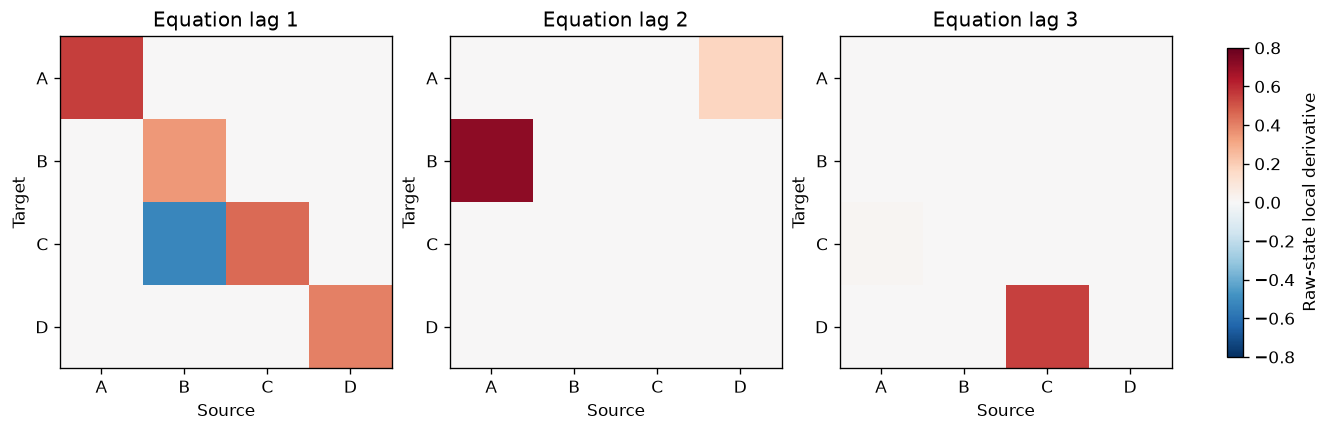

In [5]:
def equation_jacobian(h):
    out = np.zeros((3,4,4))
    out[0] = np.diag([.55,.35,.45,.40])
    out[0,2,1] = -.60/(np.cosh(h[-1,1])**2)+.30*h[-3,0]
    out[1,0,3] = .25*np.cos(h[-2,3])
    out[1,1,0] = .80/(np.cosh(h[-2,0])**2)
    out[2,2,0] = .30*h[-1,1]
    out[2,3,2] = .70/(np.cosh(h[-3,2])**2)
    return out

anchor_history = recordings[20,98:101]
jac = equation_jacobian(anchor_history)
for k in range(1,4):
    for source in range(4):
        plus, minus = anchor_history.copy(), anchor_history.copy()
        plus[-k,source] += 1e-5; minus[-k,source] -= 1e-5
        numerical = (conditional_mean(plus)-conditional_mean(minus))/2e-5
        np.testing.assert_allclose(numerical, jac[k-1,:,source], atol=1e-8)
fig, axes = plt.subplots(1,3,figsize=(11,3.8),layout="constrained")
for k,ax in enumerate(axes):
    im=ax.imshow(jac[k],vmin=-.8,vmax=.8,cmap='RdBu_r');ax.set(title=f'Equation lag {k+1}',xticks=range(4),yticks=range(4),xticklabels=NAMES,yticklabels=NAMES,xlabel='Source',ylabel='Target')
fig.colorbar(im,ax=axes.tolist(),label='Raw-state local derivative',shrink=.7)
# Explicit layout avoids tight_layout/colorbar incompatibility.
fig.savefig(OUT/'04_equation_derivatives.png',bbox_inches='tight');fig.savefig(OUT/'04_equation_derivatives.pdf',bbox_inches='tight');plt.show()

## 5. Run the actual repaired-path samplers

We start from a factual held-out recording, simulate a repair prefix, softly favor
low versus high values of a source, and penalize deviations of other coordinates
from that factual prefix. The future after the cut is simulated freely.

We use a one-frame source window for clarity. Placement lag ℓ=0 puts that source
frame at the cut; ℓ=2 puts it two frames before the cut. Horizon h counts forward
from the cut. Source-to-endpoint separation is ℓ+h. The NeuroPAL source window was
four frames and used a rank-12 population anchor; this toy uses an identity anchor.

The *known-law* adapter removes generator misspecification. The *learned-flow*
adapter adds it back. Both call the same archived direct/progressive estimators.
A high-particle direct estimate is a Monte Carlo reference, not exact truth.

In [6]:
class ToyAdapter:
    lag = 3
    device = torch.device('cpu')
    def __init__(self, learned=False): self.learned = learned
    def sample_standardized_next(self, neural_history, stimulus_history, *, seed):
        if self.learned:
            with torch.no_grad():
                return flow.sample(neural_history.reshape(-1,12),1,seed)[:,0]+neural_history[:,-1]
        h = neural_history.numpy()*scale+center
        rng = np.random.default_rng(seed)
        y = conditional_mean(h)+noise_scale(h)*rng.normal(size=(len(h),4))
        return torch.tensor((y-center)/scale,dtype=torch.float32)

low, high = np.quantile(standardized[:16].reshape(-1,4),[.25,.75],axis=0)
iqr = high-low
factual = standardized[20].astype(np.float32)
stimulus = np.zeros(len(factual),np.float32)
projection = np.eye(4,dtype=np.float32)
LAGS = [0,1,2,3]; HORIZONS = [1,2,4,8]

def repaired(learned, method, lag, n, seed):
    cfg=RepairedResponseConfig(history_frames=3,repair_frames=lag+1,
        source_window_frames=1,source_lag_frames=lag,horizon_frames=tuple(HORIZONS),
        n_particles=n,anchor_rank=4,min_ess=8,epsilon_iqr_fraction=.4)
    adapter=ToyAdapter(learned)
    if method=='direct':
        prefix,future,observed=generate_path_bank(adapter,factual,stimulus,cut_time=100,config=cfg,seed=seed)
        result=estimate_repaired_responses(prefix,future,observed,projection,low,high,iqr,np.zeros(4),cfg)
    else:
        result=progressive_smc_repaired_responses(adapter,factual,stimulus,cut_time=100,
            projection=projection,source_low=low,source_high=high,source_iqr=iqr,
            thresholds=np.zeros(4),config=cfg,seed=seed,branch_factor=2,future_branch_factor=2)
    gap=result['diagnostic_achieved_gap']
    valid=result['diagnostic_valid']>0
    # Keep unsupported/negative-gap estimates missing; do not turn them into zero.
    denominator=np.where(valid&(gap>.1),gap,np.nan)
    return result['response_endpoint_mean']/denominator[:,None,None], valid, gap

results={}; support_rows=[]; start=time.perf_counter()
for label,learned,method,n in [('Known law / direct reference',False,'direct',16384),
                              ('Known law / progressive',False,'progressive',256),
                              ('Learned flow / progressive',True,'progressive',256)]:
    blocks=[]
    for lag in LAGS:
        repeats=[]
        for repeat in range(3):
            value,valid,gap=repaired(learned,method,lag,n,500+repeat)
            repeats.append(value)
            for source in range(4):support_rows.append(dict(model=label,lag=lag,repeat=repeat,source=NAMES[source],valid=bool(valid[source]),gap=float(gap[source])))
        blocks.append(repeats)
    results[label]=np.asarray(blocks) # lag, repeat, source, horizon, target
    print(label,'complete')
sampling_seconds=time.perf_counter()-start
pd.DataFrame(support_rows).to_csv(OUT/'support.csv',index=False)
np.savez_compressed(OUT/'repaired_effects.npz',**{k.replace(' / ','_').replace(' ','_'):v for k,v in results.items()},lags=LAGS,horizons=HORIZONS)
print(f'Sampling took {sampling_seconds:.1f}s. Inspect support.csv before interpreting a query.')

Known law / direct reference complete


Known law / progressive complete


Learned flow / progressive complete
Sampling took 6.2s. Inspect support.csv before interpreting a query.


## 6. Separate sampler variation from model error

Each panel uses placement lag 1 and horizon 1. The known-law progressive result
differs from the direct reference because of finite-particle error. The learned
flow result also includes approximation error. Three repetitions reveal some
Monte Carlo variability; they do not establish calibrated uncertainty or universal
performance. Diagonals are shown here for intuition, unlike atlas scoring.

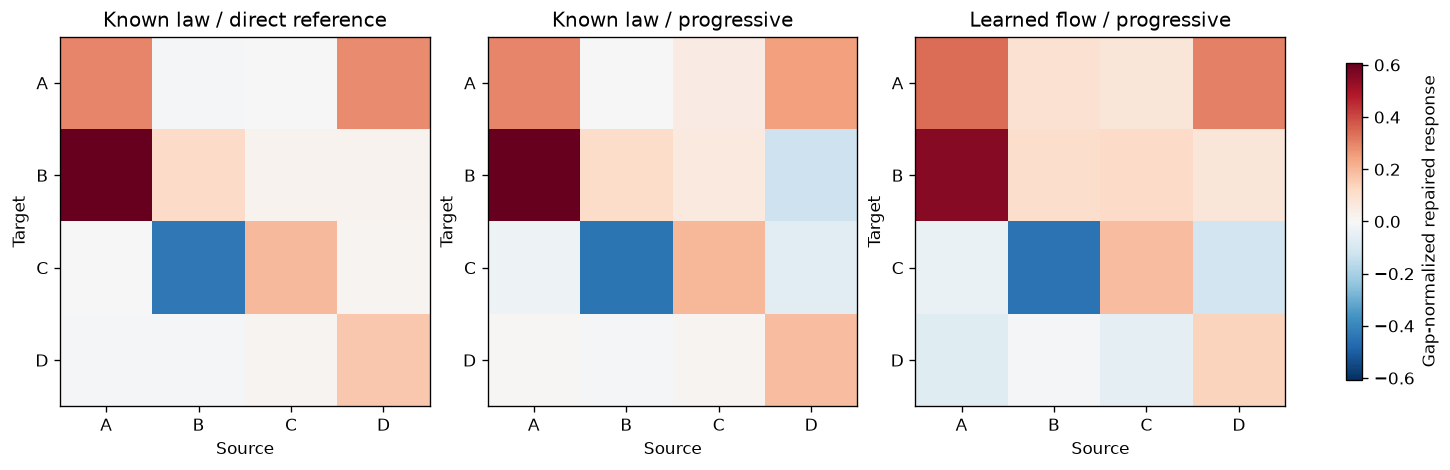

Known law / progressive MAE on resolved common cells: 0.01997118152285431 coverage: 0.9140625
Learned flow / progressive MAE on resolved common cells: 0.03687706297722897 coverage: 0.9140625


In [7]:
means={name:value.mean(axis=1) for name,value in results.items()}
fig,axes=plt.subplots(1,3,figsize=(12,4),layout="constrained")
limit=max(np.nanmax(abs(v[1,:,0,:])) for v in means.values())
for ax,(name,value) in zip(axes,means.items()):
    im=ax.imshow(value[1,:,0,:].T,cmap='RdBu_r',vmin=-limit,vmax=limit)
    ax.set(title=name,xticks=range(4),yticks=range(4),xticklabels=NAMES,yticklabels=NAMES,xlabel='Source',ylabel='Target')
fig.colorbar(im,ax=axes.tolist(),label='Gap-normalized repaired response',shrink=.7)
fig.savefig(OUT/'05_repaired_matrices.png',bbox_inches='tight');fig.savefig(OUT/'05_repaired_matrices.pdf',bbox_inches='tight');plt.show()
ref=results['Known law / direct reference']; reference_ok=np.isfinite(ref).all(axis=1)&(np.std(ref,axis=1,ddof=1)<.05)
for label in list(results)[1:]:
    v=means[label];mask=reference_ok&np.isfinite(v)
    print(label,'MAE on resolved common cells:',float(np.abs(v-ref.mean(1))[mask].mean()),'coverage:',float(mask.mean()))

## 7. Distinguish placement lag from forecast horizon

The same source→target pair yields a two-dimensional response surface. A maximum
can move because of persistence, indirect paths, nonlinear state dependence,
constraints, model error or sampling error. It need not identify an equation lag.
Here we preselect A→B because its equation explicitly contains A(t−2), rather than
selecting the most impressive estimated pair after inspecting the matrices.

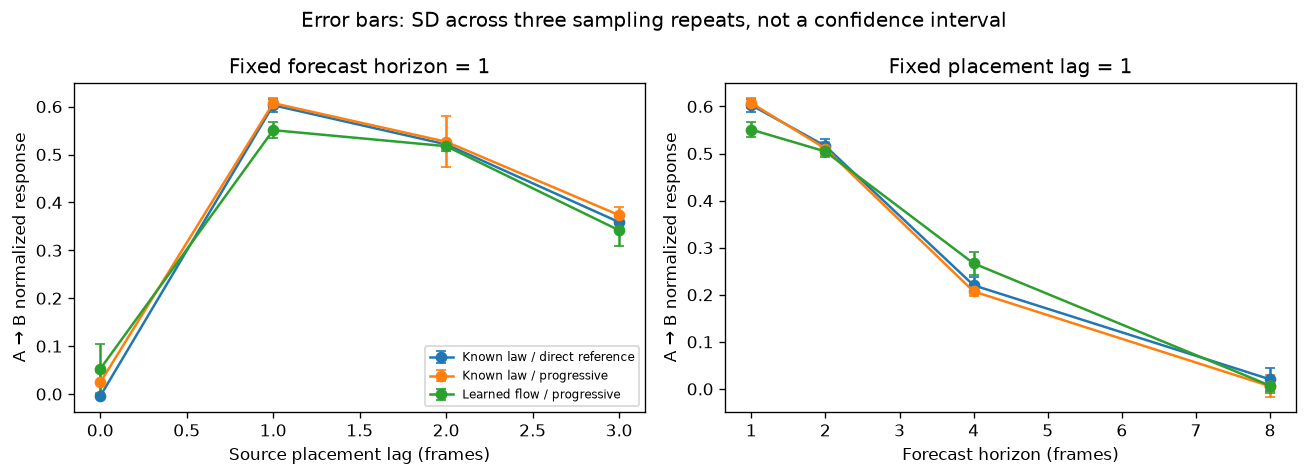

In [8]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
for name,value in results.items():
    v=value[:,:,0,0,1]
    axes[0].errorbar(LAGS,v.mean(1),yerr=v.std(1,ddof=1),marker='o',capsize=3,label=name)
    v=value[1,:,0,:,1]
    axes[1].errorbar(HORIZONS,v.mean(0),yerr=v.std(0,ddof=1),marker='o',capsize=3,label=name)
axes[0].set(xlabel='Source placement lag (frames)',ylabel='A → B normalized response',title='Fixed forecast horizon = 1')
axes[1].set(xlabel='Forecast horizon (frames)',ylabel='A → B normalized response',title='Fixed placement lag = 1')
axes[0].legend(fontsize=7);fig.suptitle('Error bars: SD across three sampling repeats, not a confidence interval')
save_figure(fig,'06_two_lag_axes')

## 8. A known intervention is a different experiment

Now directly change A in the past history and propagate the known equations using
paired future noise. We can call this an intervention because we constructed and
control this simulator. We do not anchor other states back toward the factual path.
The resulting impulse response is therefore not the repaired conditional contrast.

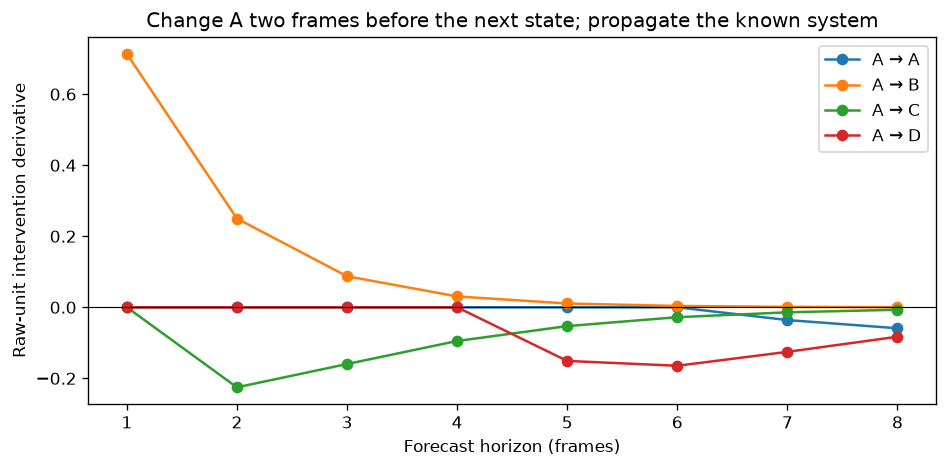

In [9]:
def intervention_response(source=0, history_lag=2, step=.05, n=20000, horizon=8):
    base=np.repeat(anchor_history[None],n,axis=0)
    a,b=base.copy(),base.copy();a[:,-history_lag,source]-=step;b[:,-history_lag,source]+=step
    rng=np.random.default_rng(700);responses=[]
    for _ in range(horizon):
        eps=rng.normal(size=(n,4))
        ya=conditional_mean(a)+noise_scale(a)*eps;yb=conditional_mean(b)+noise_scale(b)*eps
        responses.append(((yb-ya)/(2*step)).mean(0))
        a=np.concatenate([a[:,1:],ya[:,None]],axis=1);b=np.concatenate([b[:,1:],yb[:,None]],axis=1)
    return np.asarray(responses)
impulse=intervention_response()
np.savez_compressed(OUT/'known_derivatives.npz', equation_jacobian=jac, intervention_response=impulse, anchor_history=anchor_history)
fig,ax=plt.subplots(figsize=(8,4))
for j in range(4):ax.plot(np.arange(1,9),impulse[:,j],'o-',label='A → '+NAMES[j])
ax.axhline(0,color='k',lw=.7);ax.set(xlabel='Forecast horizon (frames)',ylabel='Raw-unit intervention derivative',title='Change A two frames before the next state; propagate the known system');ax.legend()
save_figure(fig,'07_known_intervention')

## 9. Exercise and interpretation

**Exercise:** reduce the source contrast by a factor of four. Does the normalized
response stabilize, or does its Monte Carlo variability grow? Increase particle
count separately. Predict the change before running it. A stable answer can still
be wrong when the generator is misspecified, as the larger benchmark shows.

**Answer scaffold:** use the same trained flow and call `repaired` after temporarily
moving `low` and `high` toward their midpoint; restore them afterward. Use several
independent seeds and compare the mean change with repeat SD. Keep bandwidth
conventions explicit; changing bandwidth changes the soft query itself.

What this notebook establishes: the pipeline is executable on a known nonlinear
system, its local analytic derivatives agree with finite differences, and we can
compare repaired responses under an exact transition law versus a fitted flow.
It does not establish universal sampler superiority, complete uncertainty coverage,
or identify a biological causal matrix. Only one generator initialization and one
response anchor are used here; the published synthetic comparison is broader.

In [10]:
summary={'seed':401,'recordings':24,'training_recordings':16,'validation_recordings':4,
         'test_recordings':4,'best_epoch':int(best_epoch),'training_epochs':len(trace),
         'training_seconds':training_seconds,'sampling_seconds':sampling_seconds,
         'heldout_mean_rmse_standardized':mean_rmse,
         'reference_resolved_fraction':float(reference_ok.mean()),
         'analytic_jacobian_check':'passed for all 48 entries',
         'interpretation':'educational single-fit/single-anchor synthetic demonstration'}
(OUT/'summary.json').write_text(json.dumps(summary,indent=2)+'\n')
summary

{'seed': 401,
 'recordings': 24,
 'training_recordings': 16,
 'validation_recordings': 4,
 'test_recordings': 4,
 'best_epoch': 61,
 'training_epochs': 82,
 'training_seconds': 0.8310275420003563,
 'sampling_seconds': 6.243373874999634,
 'heldout_mean_rmse_standardized': 0.08039520590884987,
 'reference_resolved_fraction': 0.9140625,
 'analytic_jacobian_check': 'passed for all 48 entries',
 'interpretation': 'educational single-fit/single-anchor synthetic demonstration'}